# **1**

In [1]:
import os
import json
import random
from datetime import datetime

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import pennylane as qml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## 1.1 — Carpetas base


In [2]:
BASE_DATA_DIR = r"C:\Users\lapic\datasets\z64_dimensionality_reduction_5fold"

BASE_RESULTS_DIR = r"C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN_z64_reductions_batched"

os.makedirs(BASE_RESULTS_DIR, exist_ok=True)

## 1.2 — Selección del experimento

Métodos disponibles:
- "PCA"
- "ICA"
- "AE_linear"
- "AE_nonlinear"


In [3]:
METHOD = "PCA"
FOLD = 0
K = 3

METHOD_FILES = {
    "PCA": "PCA_z1_to_z15_stratified5.npz",
    "ICA": "ICA_z1_to_z15_stratified5.npz",
    "AE_linear": "AE_linear_z1_to_z15_stratified5.npz",
    "AE_nonlinear": "AE_nonlinear_z1_to_z15_stratified5.npz",
}

assert METHOD in METHOD_FILES, (f"METHOD inválido: {METHOD}. " f"Usa {list(METHOD_FILES.keys())}")
assert FOLD in [0, 1, 2, 3, 4], ("FOLD debe ser 0, 1, 2, 3 o 4")
assert K in [1, 2, 3], ("Para esta DR-QNN, K debe ser 1, 2 o 3")

DATA_PATH = os.path.join(BASE_DATA_DIR, METHOD_FILES[METHOD])

assert os.path.exists(DATA_PATH), (f"No existe el archivo: {DATA_PATH}")

## 1.3 — Nombre del experimento


In [4]:
EXPERIMENT_NAME = (f"DR_QNN_BATCHED_{METHOD}_z{K}_fold{FOLD}")
RESULTS_DIR = os.path.join(BASE_RESULTS_DIR, EXPERIMENT_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)

## 1.4 — Configuración del dataset


In [5]:
USE_SUBSET = False
N_TRAIN_QML = 200
N_TEST_QML = 120
SUBSET_RANDOM_STATE = 123

## 1.5 — Configuración DR-QNN


In [6]:
N_LAYERS = 6
QUBITS_LIST = [1, 2, 3, 4, 5]
assert QUBITS_LIST == [1, 2, 3, 4, 5]

## 1.6 — Configuración de rapidez tipo MS-HQCNN


In [7]:
USE_VECTORIZED_QNODE = True

# Mini-batches de entrenamiento.
BATCH_SIZE = 32

# Tamaño de bloque utilizado únicamente para evaluación/inferencia.
CHUNK_SAMPLES = 131072

assert BATCH_SIZE > 0
assert CHUNK_SAMPLES > 0

## 1.7 — Entrenamiento


In [8]:
EPOCHS_1Q = 60
EPOCHS_NQ = 50

# Learning rate de la DR-QNN de un qubit.
LR_1Q = 0.006

# Al expandir el modelo, se utiliza una tasa menor para no destruir
# los parámetros heredados del modelo anterior.
LR_NQ = 0.003

## 1.8 — Backend cuántico


In [9]:
QML_DEVICE_NAME = "default.qubit"
SHOTS = None
assert QML_DEVICE_NAME in ["default.qubit"]

## 1.9 — Reproducibilidad


In [10]:
GLOBAL_SEED = 42

def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_global_seed(GLOBAL_SEED)

## 1.10 — Dispositivo PyTorch


In [11]:
TORCH_DEVICE = ("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
print(TORCH_DEVICE)

cuda


## 1.11 — Rutas de guardado


In [13]:
CONFIG_PATH = os.path.join(RESULTS_DIR, "config.json")
LOAD_SUMMARY_PATH = os.path.join(RESULTS_DIR, "load_summary.json")
METRICS_PATH = os.path.join(RESULTS_DIR, "metrics_summary.csv")
PREDICTIONS_PATH = os.path.join(RESULTS_DIR, "predictions.csv")
CHECKPOINT_1Q_PATH = os.path.join(RESULTS_DIR, "best_dr_qnn_1q.pt")
CHECKPOINT_2Q_PATH = os.path.join(RESULTS_DIR, "best_dr_qnn_2q.pt")
CHECKPOINT_3Q_PATH = os.path.join(RESULTS_DIR,"best_dr_qnn_3q.pt")
CHECKPOINT_4Q_PATH = os.path.join(RESULTS_DIR,"best_dr_qnn_4q.pt")
CHECKPOINT_5Q_PATH = os.path.join(RESULTS_DIR,"best_dr_qnn_5q.pt")

## 1.12 — Guardar configuración


In [14]:
CONFIG = {"experiment_name": EXPERIMENT_NAME, "method": METHOD, "fold": FOLD, "k": K, "data_path": DATA_PATH, "results_dir": RESULTS_DIR, "use_subset": USE_SUBSET, "n_train_qml": N_TRAIN_QML, "n_test_qml": N_TEST_QML, "subset_random_state": SUBSET_RANDOM_STATE, "n_layers": N_LAYERS, "qubits_list": QUBITS_LIST, "use_vectorized_qnode": USE_VECTORIZED_QNODE, "batch_size": BATCH_SIZE, "chunk_samples": CHUNK_SAMPLES, "epochs_1q": EPOCHS_1Q, "epochs_nq": EPOCHS_NQ, "lr_1q": LR_1Q, "lr_nq": LR_NQ, "qml_device_name": QML_DEVICE_NAME, "shots": SHOTS, "global_seed": GLOBAL_SEED, "torch_device": TORCH_DEVICE, "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(CONFIG, f, indent=4, ensure_ascii=False)

## 1.13 — Resumen


In [15]:
print("=" * 80)
print("CONFIGURACIÓN DEL EXPERIMENTO")
print("=" * 80)
print("METHOD:", METHOD)
print("FOLD:", FOLD)
print("K:", K)
print("\nDATA_PATH:")
print(DATA_PATH)
print("\nRESULTS_DIR:")
print(RESULTS_DIR)
print("\nQUBITS_LIST:", QUBITS_LIST)
print("N_LAYERS:", N_LAYERS)
print("USE_VECTORIZED_QNODE:", USE_VECTORIZED_QNODE)
print("CHUNK_SAMPLES:", CHUNK_SAMPLES)
print("BATCH_SIZE:", BATCH_SIZE)
print("QML_DEVICE_NAME:", QML_DEVICE_NAME)
print("TORCH_DEVICE:", TORCH_DEVICE)
print("\nCONFIG_PATH:")
print(CONFIG_PATH)

CONFIGURACIÓN DEL EXPERIMENTO
METHOD: PCA
FOLD: 0
K: 3

DATA_PATH:
C:\Users\lapic\datasets\z64_dimensionality_reduction_5fold\PCA_z1_to_z15_stratified5.npz

RESULTS_DIR:
C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN_z64_reductions_batched\DR_QNN_BATCHED_PCA_z3_fold0

QUBITS_LIST: [1, 2, 3, 4, 5]
N_LAYERS: 6
USE_VECTORIZED_QNODE: True
CHUNK_SAMPLES: 131072
BATCH_SIZE: 32
QML_DEVICE_NAME: default.qubit
TORCH_DEVICE: cuda

CONFIG_PATH:
C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN_z64_reductions_batched\DR_QNN_BATCHED_PCA_z3_fold0\config.json


# **2**

## 2.1 — Cargar archivo .npz


In [16]:
print("=" * 80)
print("CARGANDO DATASET")
print("=" * 80)

data = np.load(DATA_PATH, allow_pickle=True)

print("Archivo:")
print(DATA_PATH)

print("\nTotal de keys:", len(data.files))

print("\nPrimeras 20 keys:")
for key in data.files[:20]:
    print(key)

CARGANDO DATASET
Archivo:
C:\Users\lapic\datasets\z64_dimensionality_reduction_5fold\PCA_z1_to_z15_stratified5.npz

Total de keys: 216

Primeras 20 keys:
metadata
fold0_train_idx
fold0_test_idx
fold0_y_train
fold0_y_test
fold0_z64_train
fold0_z64_test
fold0_scaler_mean
fold0_scaler_scale
fold0_pca_components
fold0_pca_mean
fold0_explained_variance
fold0_explained_variance_ratio
fold0_explained_variance_ratio_cumsum
fold0_z1_train
fold0_z1_test
fold0_z2_train
fold0_z2_test
fold0_z3_train
fold0_z3_test


## 2.2 — Leer metadata


In [17]:
if "metadata" in data.files:
    metadata = json.loads(str(data["metadata"].item()))
    print("\nMetadata:")
    for key, value in metadata.items():
        print(f"{key:30s}: {value}")

else:
    metadata = {}
    print("\nNo se encontró key 'metadata'.")


Metadata:
method                        : PCA
source_file                   : /content/drive/MyDrive/BCAM/distr_sol_pv_segm_embeddings_v2.npz
x_key                         : features
y_key                         : label
original_dim                  : 64
n_samples                     : 20976
max_components                : 15
n_splits                      : 5
stratified                    : True
random_state                  : 42
created_time                  : 2026-06-22 11:12:50
note                          : Transforms are fitted only on train data inside each fold. Test data is never used to fit scaler/PCA/ICA/AE.


## 2.3 — Cargar fold y dimensión K con keys fijas


In [18]:
X_train = data[f"fold{FOLD}_z{K}_train"].astype(np.float32)
X_test = data[f"fold{FOLD}_z{K}_test"].astype(np.float32)
y_train = data[f"fold{FOLD}_y_train"].astype(int)
y_test = data[f"fold{FOLD}_y_test"].astype(int)

train_idx = data[f"fold{FOLD}_train_idx"]
test_idx = data[f"fold{FOLD}_test_idx"]

print("\nFold seleccionado:", FOLD)
print("Dimensión seleccionada K:", K)

print("\nShapes originales")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("train_idx:", train_idx.shape)
print("test_idx :", test_idx.shape)


Fold seleccionado: 0
Dimensión seleccionada K: 3

Shapes originales
X_train: (16780, 3)
X_test : (4196, 3)
y_train: (16780,)
y_test : (4196,)
train_idx: (16780,)
test_idx : (4196,)


## 2.4 — Distribución de clases


In [19]:
print("\nDistribución TRAIN")
classes_train, counts_train = np.unique(y_train, return_counts=True)
for c, n in zip(classes_train, counts_train):
    print(f"Clase {c}: {n}")

print("\nDistribución TEST")
classes_test, counts_test = np.unique(y_test, return_counts=True)
for c, n in zip(classes_test, counts_test):
    print(f"Clase {c}: {n}")


Distribución TRAIN
Clase 0: 8234
Clase 1: 8546

Distribución TEST
Clase 0: 2059
Clase 1: 2137


## 2.5 — Validaciones de consistencia


In [20]:
assert len(X_train) == len(y_train), ("X_train e y_train no tienen la misma longitud")
assert len(X_test) == len(y_test), ("X_test e y_test no tienen la misma longitud")
assert X_train.ndim == 2, ("X_train debe ser matriz 2D")
assert X_test.ndim == 2, ("X_test debe ser matriz 2D")
assert X_train.shape[1] == K, (f"X_train debería tener {K} columnas")
assert X_test.shape[1] == K, (f"X_test debería tener {K} columnas")
assert set(np.unique(y_train)).issubset({0, 1}), ("y_train debe contener clases 0/1")
assert set(np.unique(y_test)).issubset({0, 1}), ("y_test debe contener clases 0/1")
assert len(train_idx) == len(y_train), ("train_idx e y_train no tienen la misma longitud")
assert len(test_idx) == len(y_test), ("test_idx e y_test no tienen la misma longitud")

print("\nConsistencia OK")


Consistencia OK


## 2.6 — Rangos de features originales


In [21]:
print("\nRangos TRAIN")
for i in range(K):
    col = X_train[:, i]
    print(
        f"Feature {i}: "
        f"min={col.min():.6f} | "
        f"max={col.max():.6f} | "
        f"mean={col.mean():.6f} | "
        f"std={col.std():.6f}"
    )

print("\nRangos TEST")
for i in range(K):
    col = X_test[:, i]
    print(
        f"Feature {i}: "
        f"min={col.min():.6f} | "
        f"max={col.max():.6f} | "
        f"mean={col.mean():.6f} | "
        f"std={col.std():.6f}"
    )


Rangos TRAIN
Feature 0: min=-10.666145 | max=41.466248 | mean=-0.000000 | std=6.685945
Feature 1: min=-28.850418 | max=12.026334 | mean=0.000000 | std=3.076850
Feature 2: min=-16.995966 | max=8.794811 | mean=-0.000000 | std=2.058410

Rangos TEST
Feature 0: min=-10.641733 | max=34.519234 | mean=-0.091607 | std=6.515491
Feature 1: min=-15.168231 | max=11.268018 | mean=-0.046778 | std=2.994284
Feature 2: min=-15.346264 | max=7.241894 | mean=0.095289 | std=2.101738


## 2.7 — Guardar resumen inicial de carga


In [22]:
initial_load_summary = {"method": METHOD, "fold": int(FOLD), "k": int(K), "data_path": DATA_PATH, "keys_count": len(data.files), "metadata": metadata, "x_train_shape": list(X_train.shape), "x_test_shape": list(X_test.shape), "y_train_shape": list(y_train.shape), "y_test_shape": list(y_test.shape), "train_idx_shape": list(train_idx.shape), "test_idx_shape": list(test_idx.shape), "train_class_distribution": {
        str(c): int(n)
        for c, n in zip(classes_train, counts_train)},
    "test_class_distribution": {
        str(c): int(n)
        for c, n in zip(classes_test, counts_test)},}

with open(LOAD_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(initial_load_summary, f, indent=4, ensure_ascii=False)

print("\nResumen inicial de carga guardado en:")
print(LOAD_SUMMARY_PATH)


Resumen inicial de carga guardado en:
C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN_z64_reductions_batched\DR_QNN_BATCHED_PCA_z3_fold0\load_summary.json


# **3**

## 3.1 — Adaptación a qml.Rot(phi, theta, omega)


qml.Rot(phi, theta, omega) requiere 3 entradas:
- K = 3: se deja igual
- K = 2: agrega una columna de ceros
- K = 1: agrega dos columnas de cerosm

In [23]:
def adapt_to_rot_dimension(X):

    X = np.asarray(X ,dtype=np.float32)
    if X.ndim != 2:
        raise ValueError(f"X debe ser matriz 2D, llegó {X.shape}")
    if X.shape[1] == 3:
        return X.astype(np.float32)
    if X.shape[1] == 2:
        zeros = np.zeros((len(X), 1), dtype=np.float32)
        return np.concatenate([X, zeros], axis=1).astype(np.float32)
    if X.shape[1] == 1:
        zeros = np.zeros((len(X), 2), dtype=np.float32)
        return np.concatenate([X, zeros], axis=1).astype(np.float32)
    raise ValueError(f"Dimensión no soportada: {X.shape[1]}")

## 3.2 — Adaptar TRAIN y TEST


In [24]:
# ============================================================
# Adaptación a tres ángulos + escalado angular
# ============================================================

X_train_rot_raw = adapt_to_rot_dimension(X_train)
X_test_rot_raw = adapt_to_rot_dimension(X_test)

# El escalador se ajusta exclusivamente con TRAIN.
# TEST solamente se transforma con los parámetros aprendidos en TRAIN.
ANGLE_MIN = -np.pi / 2
ANGLE_MAX = np.pi / 2

angle_scaler = MinMaxScaler(
    feature_range=(ANGLE_MIN, ANGLE_MAX)
)

X_train_rot = angle_scaler.fit_transform(
    X_train_rot_raw
).astype(np.float32)

X_test_rot = angle_scaler.transform(
    X_test_rot_raw
).astype(np.float32)

# Protección ante valores de TEST fuera del rango observado en TRAIN.
X_train_rot = np.clip(
    X_train_rot,
    ANGLE_MIN,
    ANGLE_MAX
).astype(np.float32)

X_test_rot = np.clip(
    X_test_rot,
    ANGLE_MIN,
    ANGLE_MAX
).astype(np.float32)

print("\nShapes adaptadas para qml.Rot")
print("X_train_rot:", X_train_rot.shape)
print("X_test_rot :", X_test_rot.shape)

print("\nIntervalo angular aplicado:")
print(f"[{ANGLE_MIN:.6f}, {ANGLE_MAX:.6f}]")

print("\nRangos finales TRAIN")
for i, name in enumerate(["phi", "theta", "omega"]):
    col = X_train_rot[:, i]
    print(
        f"{name:>6s}: "
        f"min={col.min():.6f} | "
        f"max={col.max():.6f} | "
        f"mean={col.mean():.6f} | "
        f"std={col.std():.6f}"
    )

print("\nRangos finales TEST")
for i, name in enumerate(["phi", "theta", "omega"]):
    col = X_test_rot[:, i]
    print(
        f"{name:>6s}: "
        f"min={col.min():.6f} | "
        f"max={col.max():.6f} | "
        f"mean={col.mean():.6f} | "
        f"std={col.std():.6f}"
    )


Shapes adaptadas para qml.Rot
X_train_rot: (16780, 3)
X_test_rot : (4196, 3)

Intervalo angular aplicado:
[-1.570796, 1.570796]

Rangos finales TRAIN
   phi: min=-1.570796 | max=1.570796 | mean=-0.928035 | std=0.402907
 theta: min=-1.570796 | max=1.570796 | mean=0.646510 | std=0.236472
 omega: min=-1.570796 | max=1.570796 | mean=0.499494 | std=0.250736

Rangos finales TEST
   phi: min=-1.569325 | max=1.152157 | mean=-0.933555 | std=0.392635
 theta: min=-0.519248 | max=1.512516 | mean=0.642914 | std=0.230126
 omega: min=-1.369845 | max=1.381634 | mean=0.511101 | std=0.256014


## 3.3 — Validaciones


In [25]:
assert X_train_rot.ndim == 2
assert X_test_rot.ndim == 2

assert X_train_rot.shape[1] == 3
assert X_test_rot.shape[1] == 3

print("\nAdaptación K → 3 correcta")


Adaptación K → 3 correcta


## 3.4 — Verificar padding


In [26]:
X_train_rot = np.clip(
    X_train_rot,
    ANGLE_MIN,
    ANGLE_MAX
).astype(np.float32)

X_test_rot = np.clip(
    X_test_rot,
    ANGLE_MIN,
    ANGLE_MAX
).astype(np.float32)

# Restaurar explícitamente el padding usado por qml.Rot.
if K == 1:
    X_train_rot[:, 1:] = 0.0
    X_test_rot[:, 1:] = 0.0

elif K == 2:
    X_train_rot[:, 2] = 0.0
    X_test_rot[:, 2] = 0.0

## 3.5 — Vista rápida


In [27]:
preview_df = pd.DataFrame(X_train_rot[:10], columns=["phi", "theta", "omega"])
preview_df["label"] = y_train[:10]
display(preview_df)

,phi,theta,omega,label
0,-1.266851,0.665552,0.616182,0
1,-0.466618,1.085120,0.835216,1
2,-0.934083,0.851753,0.375980,1
3,-0.488157,0.912921,0.653943,1
4,-1.152836,0.596186,0.463660,1
5,-1.199830,0.554172,0.803514,0
6,-0.611373,0.049513,0.131243,0
7,-1.008771,0.769307,0.353635,1
8,-1.297738,0.713532,0.511872,0
9,-1.030498,0.471045,0.362059,0


## 3.6 — Estadísticas después de la adaptación


In [28]:
print("\nRangos TRAIN adaptado")
for i, name in enumerate(["phi", "theta", "omega"]):
    col = X_train_rot[:, i]
    print(
        f"{name:>6s}: "
        f"min={col.min():.6f} | "
        f"max={col.max():.6f} | "
        f"mean={col.mean():.6f} | "
        f"std={col.std():.6f}"
    )

print("\nRangos TEST adaptado")
for i, name in enumerate(["phi", "theta", "omega"]):
    col = X_test_rot[:, i]
    print(
        f"{name:>6s}: "
        f"min={col.min():.6f} | "
        f"max={col.max():.6f} | "
        f"mean={col.mean():.6f} | "
        f"std={col.std():.6f}"
    )


Rangos TRAIN adaptado
   phi: min=-1.570796 | max=1.570796 | mean=-0.928035 | std=0.402907
 theta: min=-1.570796 | max=1.570796 | mean=0.646510 | std=0.236472
 omega: min=-1.570796 | max=1.570796 | mean=0.499494 | std=0.250736

Rangos TEST adaptado
   phi: min=-1.569325 | max=1.152157 | mean=-0.933555 | std=0.392635
 theta: min=-0.519248 | max=1.512516 | mean=0.642914 | std=0.230126
 omega: min=-1.369845 | max=1.381634 | mean=0.511101 | std=0.256014


## 3.7 — Resumen


In [29]:
print("\nResumen adaptación")
print("K original:" ,K)
print("Dimensión final para DR-QNN:", X_train_rot.shape[1])
print("TRAIN:", X_train_rot.shape)
print("TEST :", X_test_rot.shape)


Resumen adaptación
K original: 3
Dimensión final para DR-QNN: 3
TRAIN: (16780, 3)
TEST : (4196, 3)


# **4**

## 4.1 — Construir dataset que verá la DR-QNN


In [30]:
if USE_SUBSET:
    train_positions = np.arange(len(X_train_rot))
    test_positions = np.arange(len(X_test_rot))

    train_subset, _ = train_test_split(train_positions, train_size=N_TRAIN_QML, stratify=y_train, random_state=SUBSET_RANDOM_STATE)
    test_subset, _ = train_test_split(test_positions, train_size=N_TEST_QML, stratify=y_test, random_state=SUBSET_RANDOM_STATE)

    X_train_qml = X_train_rot[train_subset].copy()
    y_train_qml = y_train[train_subset].copy()

    X_test_qml = X_test_rot[test_subset].copy()
    y_test_qml = y_test[test_subset].copy()

    original_train_idx_qml = train_idx[train_subset].copy()
    original_test_idx_qml = test_idx[test_subset].copy()

else:
    X_train_qml = X_train_rot.copy()
    y_train_qml = y_train.copy()

    X_test_qml = X_test_rot.copy()
    y_test_qml = y_test.copy()

    original_train_idx_qml = train_idx.copy()
    original_test_idx_qml = test_idx.copy()

## 4.2 — Validaciones del dataset QML


In [31]:
assert X_train_qml.ndim == 2
assert X_test_qml.ndim == 2

assert X_train_qml.shape[1] == 3
assert X_test_qml.shape[1] == 3

assert len(X_train_qml) == len(y_train_qml)
assert len(X_test_qml) == len(y_test_qml)

assert len(original_train_idx_qml) == len(y_train_qml)
assert len(original_test_idx_qml) == len(y_test_qml)

assert set(np.unique(y_train_qml)).issubset(
    {0, 1}
)

assert set(np.unique(y_test_qml)).issubset(
    {0, 1}
)

## 4.3 — Resumen del dataset final


In [32]:
print("\nDataset que verá la DR-QNN")
print("X_train_qml:", X_train_qml.shape)
print("X_test_qml :", X_test_qml.shape)
print("\ny_train_qml:", y_train_qml.shape)
print("y_test_qml :", y_test_qml.shape)
print("\nÍndices originales:")
print("original_train_idx_qml:", original_train_idx_qml.shape)
print("original_test_idx_qml :", original_test_idx_qml.shape)

print("\nClases TRAIN QML:")
classes_train_qml, counts_train_qml = np.unique(y_train_qml, return_counts=True)
for c, n in zip(classes_train_qml, counts_train_qml):
    print(f"Clase {c}: {n}")

print("\nClases TEST QML:")
classes_test_qml, counts_test_qml = np.unique(y_test_qml, return_counts=True)
for c, n in zip(classes_test_qml, counts_test_qml):
    print(f"Clase {c}: {n}")


Dataset que verá la DR-QNN
X_train_qml: (16780, 3)
X_test_qml : (4196, 3)

y_train_qml: (16780,)
y_test_qml : (4196,)

Índices originales:
original_train_idx_qml: (16780,)
original_test_idx_qml : (4196,)

Clases TRAIN QML:
Clase 0: 8234
Clase 1: 8546

Clases TEST QML:
Clase 0: 2059
Clase 1: 2137


## 4.4 — Definir tamaño de batch/chunk para entrenamiento


In [33]:
if BATCH_SIZE is None:
    TRAIN_BATCH_SIZE = len(X_train_qml)
    FULL_BATCH_TRAINING = True

else:
    TRAIN_BATCH_SIZE = BATCH_SIZE
    FULL_BATCH_TRAINING = False

EVAL_CHUNK_SIZE = CHUNK_SAMPLES

assert TRAIN_BATCH_SIZE > 0
assert EVAL_CHUNK_SIZE > 0

print("\nConfiguración de batches")
print("FULL_BATCH_TRAINING:", FULL_BATCH_TRAINING)
print("TRAIN_BATCH_SIZE:", TRAIN_BATCH_SIZE)
print("EVAL_CHUNK_SIZE :", EVAL_CHUNK_SIZE)


Configuración de batches
FULL_BATCH_TRAINING: False
TRAIN_BATCH_SIZE: 32
EVAL_CHUNK_SIZE : 131072


## 4.5 — Función para generar batches de índices


In [34]:
def make_batch_indices(n_samples, batch_size, shuffle=True, seed=None):

    indices = np.arange(n_samples)

    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(indices)
    batches = []

    for start in range(0,n_samples,batch_size):
        end = min(start + batch_size,n_samples)
        batches.append(indices[start:end])

    return batches

## 4.6 — Sanity check de batches de entrenamiento


In [35]:
train_batches_preview = make_batch_indices(n_samples=len(X_train_qml) ,batch_size=TRAIN_BATCH_SIZE, shuffle=True, seed=GLOBAL_SEED)

print("\nNúmero de batches TRAIN por época:")
print(len(train_batches_preview))

print("\nPrimeros tamaños de batch:")

for b in train_batches_preview[:5]:
    print(len(b))

assert sum(len(b) for b in train_batches_preview) == len(X_train_qml)


Número de batches TRAIN por época:
525

Primeros tamaños de batch:
32
32
32
32
32


## 4.7 — Función para iterar arrays NumPy por batches


In [36]:
def iter_numpy_batches(X, y=None, batch_size=1024, shuffle=False, seed=None):
    batches = make_batch_indices(n_samples=len(X), batch_size=batch_size, shuffle=shuffle, seed=seed)
    for batch_idx in batches:
        if y is None:
            yield X[batch_idx]
        else:
            yield X[batch_idx], y[batch_idx]

## 4.8 — Sanity check de iterador NumPy


In [37]:
first_batch = next(iter_numpy_batches(X_train_qml, y_train_qml, batch_size=TRAIN_BATCH_SIZE, shuffle=True, seed=GLOBAL_SEED))
first_X_batch, first_y_batch = first_batch

print("\nPrimer batch NumPy")
print("X:", first_X_batch.shape)
print("y:", first_y_batch.shape)

assert first_X_batch.ndim == 2
assert first_X_batch.shape[1] == 3
assert len(first_X_batch) == len(first_y_batch)


Primer batch NumPy
X: (32, 3)
y: (32,)


## 4.9 — Guardar resumen actualizado


In [38]:
initial_load_summary.update({
        "x_train_qml_shape": list(X_train_qml.shape),
        "x_test_qml_shape": list(X_test_qml.shape),
        "y_train_qml_shape": list(y_train_qml.shape),
        "y_test_qml_shape": list(y_test_qml.shape),
        "original_train_idx_qml_shape": list(original_train_idx_qml.shape),
        "original_test_idx_qml_shape": list(original_test_idx_qml.shape),
        "full_batch_training": bool(FULL_BATCH_TRAINING),
        "train_batch_size": int(TRAIN_BATCH_SIZE),
        "eval_chunk_size": int(EVAL_CHUNK_SIZE),
        "train_qml_class_distribution": {
            str(c): int(n)
            for c, n in zip(classes_train_qml,counts_train_qml)},
        "test_qml_class_distribution": {
            str(c): int(n)
            for c, n in zip(classes_test_qml,counts_test_qml)},
    })

with open(LOAD_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(initial_load_summary, f, indent=4, ensure_ascii=False)

print("\nResumen actualizado guardado en:")
print(LOAD_SUMMARY_PATH)


Resumen actualizado guardado en:
C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN_z64_reductions_batched\DR_QNN_BATCHED_PCA_z3_fold0\load_summary.json


# **5**

## 5.1 — Dispositivo y tensorización


In [39]:
DEVICE = torch.device(TORCH_DEVICE)

X_train_t = torch.tensor(X_train_qml, dtype=torch.float32, device=DEVICE)
X_test_t = torch.tensor(X_test_qml, dtype=torch.float32, device=DEVICE)

y_train_t = torch.tensor(y_train_qml, dtype=torch.long, device=DEVICE)
y_test_t = torch.tensor(y_test_qml, dtype=torch.long, device=DEVICE)

y_train_float_t = y_train_t.float()
y_test_float_t = y_test_t.float()

print("DEVICE:", DEVICE)

print("\nTensores en memoria:")
print("X_train_t:", X_train_t.shape, X_train_t.dtype, X_train_t.device)
print("X_test_t :", X_test_t.shape, X_test_t.dtype, X_test_t.device)
print("y_train_t:", y_train_t.shape, y_train_t.dtype, y_train_t.device)
print("y_test_t :", y_test_t.shape, y_test_t.dtype, y_test_t.device)

DEVICE: cuda

Tensores en memoria:
X_train_t: torch.Size([16780, 3]) torch.float32 cuda:0
X_test_t : torch.Size([4196, 3]) torch.float32 cuda:0
y_train_t: torch.Size([16780]) torch.int64 cuda:0
y_test_t : torch.Size([4196]) torch.int64 cuda:0


## 5.2 — Validaciones para QNode batched


In [40]:
assert X_train_t.ndim == 2
assert X_test_t.ndim == 2

assert X_train_t.shape[1] == 3
assert X_test_t.shape[1] == 3

assert len(X_train_t) == len(y_train_t)
assert len(X_test_t) == len(y_test_t)

assert set(
    y_train_t.detach().cpu().numpy().tolist()
).issubset({0, 1})

assert set(
    y_test_t.detach().cpu().numpy().tolist()
).issubset({0, 1})

print("\nValidaciones tensoriales OK")
print("Entrada esperada por QNode batched: (B, 3)")


Validaciones tensoriales OK
Entrada esperada por QNode batched: (B, 3)


## 5.3 — Función de batches tensoriales

In [41]:
def make_tensor_batches(X, y=None, batch_size=None, shuffle=True, seed=None):
    n_samples = X.shape[0]
    
    if batch_size is None:
        batch_size = n_samples
    indices = torch.arange(n_samples, device=X.device)

    if shuffle:
        generator = torch.Generator(device=X.device)

        if seed is not None:
            generator.manual_seed(int(seed))

        indices = indices[torch.randperm(n_samples, generator=generator, device=X.device)]

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        batch_idx = indices[start:end]

        if y is None:
            yield X[batch_idx]

        else:
            yield X[batch_idx], y[batch_idx]

## 5.4 — Batch size efectivo para entrenamiento

In [42]:
if BATCH_SIZE is None:

    TRAIN_BATCH_SIZE_TORCH = len(X_train_t)

    FULL_BATCH_TRAINING = True

else:

    TRAIN_BATCH_SIZE_TORCH = int(BATCH_SIZE)

    FULL_BATCH_TRAINING = False

EVAL_CHUNK_SIZE_TORCH = int(
    CHUNK_SAMPLES
)

assert TRAIN_BATCH_SIZE_TORCH > 0
assert EVAL_CHUNK_SIZE_TORCH > 0

print("\nConfiguración batched final:")
print("FULL_BATCH_TRAINING:", FULL_BATCH_TRAINING)
print("TRAIN_BATCH_SIZE_TORCH:", TRAIN_BATCH_SIZE_TORCH)
print("EVAL_CHUNK_SIZE_TORCH :", EVAL_CHUNK_SIZE_TORCH)


Configuración batched final:
FULL_BATCH_TRAINING: False
TRAIN_BATCH_SIZE_TORCH: 32
EVAL_CHUNK_SIZE_TORCH : 131072


## 5.5 — Sanity check del batch de entrenamiento


In [43]:
first_X_t, first_y_t = next(make_tensor_batches(X_train_t, y_train_float_t, batch_size=TRAIN_BATCH_SIZE_TORCH, shuffle=True, seed=GLOBAL_SEED))

print("\nPrimer batch Torch:")
print("X:", first_X_t.shape, first_X_t.dtype, first_X_t.device)
print("y:", first_y_t.shape, first_y_t.dtype, first_y_t.device)

assert first_X_t.ndim == 2
assert first_X_t.shape[1] == 3
assert len(first_X_t) == len(first_y_t)


Primer batch Torch:
X: torch.Size([32, 3]) torch.float32 cuda:0
y: torch.Size([32]) torch.float32 cuda:0


## 5.6 — Sanity check de chunks de evaluación


In [44]:
first_eval_chunk = next(make_tensor_batches(X_test_t, y_test_float_t, batch_size=EVAL_CHUNK_SIZE_TORCH, shuffle=False, seed=None))
first_X_eval_t, first_y_eval_t = first_eval_chunk

print("\nPrimer chunk de evaluación:")
print("X:", first_X_eval_t.shape, first_X_eval_t.dtype, first_X_eval_t.device)
print("y:", first_y_eval_t.shape, first_y_eval_t.dtype, first_y_eval_t.device)

assert first_X_eval_t.ndim == 2
assert first_X_eval_t.shape[1] == 3


Primer chunk de evaluación:
X: torch.Size([4196, 3]) torch.float32 cuda:0
y: torch.Size([4196]) torch.float32 cuda:0


## 5.7 — Resumen actualizado

In [45]:
initial_load_summary.update(
    {
        "torch_device": str(DEVICE),
        "x_train_t_shape": list(X_train_t.shape),
        "x_test_t_shape": list(X_test_t.shape),
        "y_train_t_shape": list(y_train_t.shape),
        "y_test_t_shape": list(y_test_t.shape),
        "full_batch_training": bool(FULL_BATCH_TRAINING),
        "train_batch_size_torch": int(TRAIN_BATCH_SIZE_TORCH),
        "eval_chunk_size_torch": int(EVAL_CHUNK_SIZE_TORCH),
        "qnode_expected_input_shape": "(B, 3)",
        "batched_qnode_required": bool(USE_VECTORIZED_QNODE),
    }
)

with open(LOAD_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(initial_load_summary, f, indent=4, ensure_ascii=False)

print("\nSección 5 lista.")
print("Los datos ya están en tensores y preparados para QNode batched.")
print("Resumen actualizado guardado en:")
print(LOAD_SUMMARY_PATH)


Sección 5 lista.
Los datos ya están en tensores y preparados para QNode batched.
Resumen actualizado guardado en:
C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN_z64_reductions_batched\DR_QNN_BATCHED_PCA_z3_fold0\load_summary.json


# **6**

## 6.1 — Crear dispositivos cuánticos


In [46]:
def make_qml_device(n_qubits):

    if QML_DEVICE_NAME == "default.qubit":
        return qml.device(QML_DEVICE_NAME, wires=n_qubits, shots=SHOTS)

    return qml.device(QML_DEVICE_NAME, wires=n_qubits, shots=SHOTS)

qml_devices = {}

for n_qubits in QUBITS_LIST:
    qml_devices[n_qubits] = make_qml_device(n_qubits)
print("Dispositivos creados:")

for n_qubits, dev in qml_devices.items():
    print(f"{n_qubits}Q:", dev)

Dispositivos creados:
1Q: <default.qubit device (wires=1) at 0x1fe59cf5090>
2Q: <default.qubit device (wires=2) at 0x1fe4874fe50>
3Q: <default.qubit device (wires=3) at 0x1fe4875f450>
4Q: <default.qubit device (wires=4) at 0x1fe4877ec90>
5Q: <default.qubit device (wires=5) at 0x1fe4877ed50>


## 6.2 — Bloques cuánticos básicos

In [47]:
def encode_data_reuploading_layer(X_batch, n_qubits):
    for q in range(n_qubits):
        qml.Rot(X_batch[:, 0], X_batch[:, 1], X_batch[:, 2], wires=q)


def apply_single_qubit_trainable_layer(theta_layer, n_qubits):
    for q in range(n_qubits):
        qml.Rot(theta_layer[q, 0], theta_layer[q, 1], theta_layer[q, 2], wires=q)


def apply_entangling_layer(phi_layer, n_qubits):
    if n_qubits == 1:
        return
    for s in range(n_qubits - 1):
        qml.ctrl(qml.Rot, control=s + 1)(phi_layer[s, 0], phi_layer[s, 1], phi_layer[s, 2], wires=s)

## 6.3 — Constructor de QNode batched para n qubits

In [48]:
def make_batched_drqnn_qnode(n_qubits):
    dev = qml_devices[n_qubits]
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    
    def qnode(X_batch, theta, phi):
        for layer in range(N_LAYERS):
            encode_data_reuploading_layer(X_batch, n_qubits)
            apply_single_qubit_trainable_layer(theta[layer], n_qubits)

            if n_qubits > 1:
                apply_entangling_layer(phi[layer], n_qubits)

        return qml.probs(wires=0)

    return qnode

## 6.4 — Crear QNodes Q1 → Q5

In [49]:
batched_qnodes = {}

for n_qubits in QUBITS_LIST:
    batched_qnodes[n_qubits] = make_batched_drqnn_qnode(n_qubits)

print("\nQNodes batched creados:")

for n_qubits in batched_qnodes:
    print(f"{n_qubits}Q listo")


QNodes batched creados:
1Q listo
2Q listo
3Q listo
4Q listo
5Q listo


## 6.5 — Inicializadores auxiliares de parámetros

In [50]:
def make_empty_theta(n_qubits, device=DEVICE):
    theta = torch.zeros(N_LAYERS, n_qubits, 3, dtype=torch.float32, device=device)
    return theta

def make_empty_phi(n_qubits, device=DEVICE):

    if n_qubits == 1:
        phi = torch.zeros(N_LAYERS, 1, 3, dtype=torch.float32, device=device)

    else:
        phi = torch.zeros(N_LAYERS, n_qubits - 1, 3, dtype=torch.float32, device=device)

    return phi

## 6.6 — Sanity check batched de todos los QNodes

In [51]:
SANITY_BATCH_SIZE = min(8, len(X_train_t))
X_sanity = X_train_t[:SANITY_BATCH_SIZE]

print("\nSanity batch:")
print("X_sanity:", X_sanity.shape)

qnode_sanity_outputs = {}

with torch.no_grad():
    for n_qubits in QUBITS_LIST:
        theta_sanity = make_empty_theta(n_qubits)
        phi_sanity = make_empty_phi(n_qubits)
        probs = batched_qnodes[n_qubits](X_sanity, theta_sanity, phi_sanity)
        qnode_sanity_outputs[n_qubits] = probs

        print(f"{n_qubits}Q probs:", probs.shape, probs.device, probs.dtype)

        assert probs.ndim == 2
        assert probs.shape[0] == SANITY_BATCH_SIZE
        assert probs.shape[1] == 2

        expected = torch.ones_like(probs.sum(dim=1))

        assert torch.allclose(probs.sum(dim=1), expected, atol=1e-5)

print("\nSanity check Q1-Q5 OK")


Sanity batch:
X_sanity: torch.Size([8, 3])
1Q probs: torch.Size([8, 2]) cuda:0 torch.float32
2Q probs: torch.Size([8, 2]) cuda:0 torch.float32
3Q probs: torch.Size([8, 2]) cuda:0 torch.float32
4Q probs: torch.Size([8, 2]) cuda:0 torch.float32
5Q probs: torch.Size([8, 2]) cuda:0 torch.float32

Sanity check Q1-Q5 OK


## 6.7 — Convención de salida


In [52]:
print("\nConvención de salida DR-QNN:")
print("probs[:, 0] = fidelidad/probabilidad asociada a clase 0")
print("probs[:, 1] = score de clase 1")
print("pred = 1 si probs[:, 1] >= 0.5")

print("\nSección 6 lista.")
print("Los QNodes ya reciben batches X_batch con shape (B, 3).")


Convención de salida DR-QNN:
probs[:, 0] = fidelidad/probabilidad asociada a clase 0
probs[:, 1] = score de clase 1
pred = 1 si probs[:, 1] >= 0.5

Sección 6 lista.
Los QNodes ya reciben batches X_batch con shape (B, 3).


In [53]:
probs.dtype

torch.float32

# **7**

## 7.1 — Clase general DR-QNN batched

In [54]:
class BatchedDRQNN(nn.Module):

    def __init__(
        self,
        n_qubits,
        init_theta=None,
        init_phi=None
    ):
        super().__init__()

        assert n_qubits in QUBITS_LIST

        self.n_qubits = n_qubits

        theta_shape = (
            N_LAYERS,
            n_qubits,
            3
        )

        phi_shape = (
            N_LAYERS,
            max(n_qubits - 1, 1),
            3
        )

        # ----------------------------------------------------
        # Rotaciones locales entrenables
        # ----------------------------------------------------
        if init_theta is None:

            theta = torch.empty(
                theta_shape,
                dtype=torch.float32,
                device=DEVICE
            )

            theta.uniform_(
                -np.pi / 2,
                np.pi / 2
            )

        else:

            theta = (
                init_theta
                .detach()
                .clone()
                .float()
                .to(DEVICE)
            )

        # ----------------------------------------------------
        # Acoplamientos controlados
        # Se mantienen en cero para que inicialmente sean identidad.
        # ----------------------------------------------------
        if init_phi is None:

            phi = torch.zeros(
                phi_shape,
                dtype=torch.float32,
                device=DEVICE
            )

        else:

            phi = (
                init_phi
                .detach()
                .clone()
                .float()
                .to(DEVICE)
            )

        assert theta.shape == theta_shape
        assert phi.shape == phi_shape

        self.theta = nn.Parameter(theta)
        self.phi = nn.Parameter(phi)

        self.qnode = batched_qnodes[n_qubits]

    def forward(self, X_batch):

        probs = self.qnode(
            X_batch,
            self.theta,
            self.phi
        )

        probs = probs.float()

        # Probabilidad asociada a la clase 1.
        score_class1 = probs[:, 1]

        return score_class1

    def predict_proba(self, X_batch):

        probs = self.qnode(
            X_batch,
            self.theta,
            self.phi
        )

        return probs.float()

## 7.2 — Funciones de transferencia Q(n) → Q(n+1)

In [55]:
def expand_theta_from_previous(
    previous_theta,
    new_n_qubits
):

    previous_theta = (
        previous_theta
        .detach()
        .clone()
        .float()
        .to(DEVICE)
    )

    old_n_qubits = previous_theta.shape[1]

    assert new_n_qubits == old_n_qubits + 1

    # Inicialización de los parámetros del modelo ampliado.
    new_theta = torch.empty(
        N_LAYERS,
        new_n_qubits,
        3,
        dtype=torch.float32,
        device=DEVICE
    )

    new_theta.uniform_(
        -np.pi / 2,
        np.pi / 2
    )

    # Conservar exactamente los parámetros de los qubits
    # que ya fueron entrenados.
    new_theta[
        :,
        :old_n_qubits,
        :
    ] = previous_theta

    return new_theta


def expand_phi_from_previous(
    previous_phi,
    new_n_qubits
):

    previous_phi = (
        previous_phi
        .detach()
        .clone()
        .float()
        .to(DEVICE)
    )

    new_phi = torch.zeros(
        N_LAYERS,
        max(new_n_qubits - 1, 1),
        3,
        dtype=torch.float32,
        device=DEVICE
    )

    if new_n_qubits > 2:

        old_phi_width = previous_phi.shape[1]

        new_phi[
            :,
            :old_phi_width,
            :
        ] = previous_phi

    return new_phi


def make_next_model_from_previous(
    previous_model,
    new_n_qubits
):

    init_theta = expand_theta_from_previous(
        previous_model.theta,
        new_n_qubits
    )

    init_phi = expand_phi_from_previous(
        previous_model.phi,
        new_n_qubits
    )

    model = BatchedDRQNN(
        n_qubits=new_n_qubits,
        init_theta=init_theta,
        init_phi=init_phi
    )

    return model


print("Funciones de expansión definidas correctamente.")

Funciones de expansión definidas correctamente.


## 7.3 — Crear modelo inicial Q1

In [56]:
model_1q = BatchedDRQNN(
    n_qubits=1
)

print("Modelo Q1 creado")
print(model_1q)

print("\nParámetros Q1:")
for name, param in model_1q.named_parameters():

    print(
        name,
        tuple(param.shape),
        param.dtype,
        param.device,
        "requires_grad=",
        param.requires_grad
    )

Modelo Q1 creado
BatchedDRQNN()

Parámetros Q1:
theta (6, 1, 3) torch.float32 cuda:0 requires_grad= True
phi (6, 1, 3) torch.float32 cuda:0 requires_grad= True


## 7.4 — Sanity check forward Q1

In [57]:
with torch.no_grad():

    q1_scores = model_1q(
        X_sanity
    )

    q1_probs = model_1q.predict_proba(
        X_sanity
    )

print("\nSanity forward Q1")
print("scores:", q1_scores.shape, q1_scores.dtype, q1_scores.device)
print("probs :", q1_probs.shape, q1_probs.dtype, q1_probs.device)

assert q1_scores.ndim == 1
assert q1_scores.shape[0] == SANITY_BATCH_SIZE
assert q1_scores.dtype == torch.float32

assert q1_probs.ndim == 2
assert q1_probs.shape == (
    SANITY_BATCH_SIZE,
    2
)
assert q1_probs.dtype == torch.float32


Sanity forward Q1
scores: torch.Size([8]) torch.float32 cuda:0
probs : torch.Size([8, 2]) torch.float32 cuda:0


## 7.5 — Sanity check expansión Q1 → Q5

In [58]:
model_sanity = model_1q

sanity_models = {
    1: model_1q
}

for next_q in QUBITS_LIST[1:]:

    model_sanity = make_next_model_from_previous(
        model_sanity,
        next_q
    )

    sanity_models[next_q] = model_sanity

    with torch.no_grad():

        scores = model_sanity(
            X_sanity
        )

        probs = model_sanity.predict_proba(
            X_sanity
        )

    print(f"\nSanity modelo Q{next_q}")
    print("scores:", scores.shape, scores.dtype, scores.device)
    print("probs :", probs.shape, probs.dtype, probs.device)

    assert scores.ndim == 1
    assert scores.shape[0] == SANITY_BATCH_SIZE
    assert scores.dtype == torch.float32

    assert probs.ndim == 2
    assert probs.shape == (
        SANITY_BATCH_SIZE,
        2
    )
    assert probs.dtype == torch.float32


Sanity modelo Q2
scores: torch.Size([8]) torch.float32 cuda:0
probs : torch.Size([8, 2]) torch.float32 cuda:0

Sanity modelo Q3
scores: torch.Size([8]) torch.float32 cuda:0
probs : torch.Size([8, 2]) torch.float32 cuda:0

Sanity modelo Q4
scores: torch.Size([8]) torch.float32 cuda:0
probs : torch.Size([8, 2]) torch.float32 cuda:0

Sanity modelo Q5
scores: torch.Size([8]) torch.float32 cuda:0
probs : torch.Size([8, 2]) torch.float32 cuda:0


## 7.6 — Convención final del modelo

In [59]:
print("\nSección 7 lista.")
print("Cada modelo recibe X_batch con shape (B, 3).")
print("Cada forward devuelve scores clase 1 con shape (B,).")
print("predict_proba devuelve probs float32 con shape (B, 2).")
print("Los QNodes devuelven float64, pero el modelo convierte a float32.")


Sección 7 lista.
Cada modelo recibe X_batch con shape (B, 3).
Cada forward devuelve scores clase 1 con shape (B,).
predict_proba devuelve probs float32 con shape (B, 2).
Los QNodes devuelven float64, pero el modelo convierte a float32.


# **8**

## 8.1 — Loss de fidelidad para clasificación binaria

In [60]:
def fidelity_loss_from_scores(
    scores_class1,
    y_batch
):
    """
    MSE entre una salida en [-1, 1] y etiquetas {-1, +1}.

    scores_class1:
        Probabilidad P(clase=1), en [0, 1].

    Convención:
        clase 0 -> -1
        clase 1 -> +1
    """

    y_batch = y_batch.float()

    # P(clase=1) en [0,1] -> score en [-1,1].
    z_class1 = 2.0 * scores_class1 - 1.0

    # Etiquetas 0/1 -> etiquetas -1/+1.
    y_pm1 = 2.0 * y_batch - 1.0

    loss = torch.mean(
        (z_class1 - y_pm1) ** 2
    )

    return loss

## 8.2 — Predicción batched sin evaluar muestra por muestra

In [61]:
@torch.no_grad()
def predict_scores_batched(model, X, chunk_size=131072):
    model.eval()
    scores_all = []
    for X_chunk in make_tensor_batches(X, y=None, batch_size=chunk_size, shuffle=False, seed=None):
        scores_chunk = model(X_chunk)
        scores_all.append(scores_chunk.detach().cpu())
    scores_all = torch.cat(scores_all, dim=0 ).numpy()

    return scores_all

## 8.3 — Métricas binarias

In [62]:
def compute_binary_metrics(y_true, scores, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores)
    y_pred = (scores >= threshold).astype(int)

    metrics = {"threshold": float(threshold), "accuracy": float( accuracy_score( y_true, y_pred)), "balanced_accuracy": float(balanced_accuracy_score( y_true, y_pred)), "f1": float(f1_score(y_true, y_pred)),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),}

    return metrics

## 8.4 — Evaluación completa batched

In [63]:
def evaluate_model(model, X, y, split_name, chunk_size=131072, threshold=0.5):
    scores = predict_scores_batched( model=model, X=X, chunk_size=chunk_size )
    y_np = y.detach().cpu().numpy()
    metrics = compute_binary_metrics( y_true=y_np, scores=scores, threshold=threshold)
    metrics["split"] = split_name
    metrics["n_samples"] = int(len(y_np))

    return metrics, scores

## 8.5 — Entrenamiento de un modelo Qn

In [64]:
def train_drqnn_model(model, n_qubits, checkpoint_path):
    if n_qubits == 1:
        epochs = EPOCHS_1Q
        lr = LR_1Q
    else:
        epochs = EPOCHS_NQ
        lr = LR_NQ
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_test_bacc = -np.inf
    best_state = None

    history = []

    print("\nEntrenando DR-QNN")
    print("Qubits:", n_qubits)
    print("Epochs:", epochs)
    print("LR:", lr)
    print("TRAIN_BATCH_SIZE_TORCH:", TRAIN_BATCH_SIZE_TORCH)

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_losses = []

        for X_batch, y_batch in make_tensor_batches(
            X_train_t,
            y_train_float_t,
            batch_size=TRAIN_BATCH_SIZE_TORCH,
            shuffle=True,
            seed=GLOBAL_SEED + epoch
        ):

            optimizer.zero_grad(set_to_none=True)
            scores = model(X_batch)
            loss = fidelity_loss_from_scores(scores, y_batch)
            loss.backward()
            optimizer.step()
            epoch_losses.append(float(loss.detach().cpu().item()))

        train_metrics, _ = evaluate_model(
            model=model,
            X=X_train_t,
            y=y_train_t,
            split_name="train",
            chunk_size=EVAL_CHUNK_SIZE_TORCH,
            threshold=0.5
        )

        test_metrics, _ = evaluate_model(
            model=model,
            X=X_test_t,
            y=y_test_t,
            split_name="test",
            chunk_size=EVAL_CHUNK_SIZE_TORCH,
            threshold=0.5
        )

        mean_loss = float(
            np.mean(epoch_losses)
        )

        row = {
            "n_qubits": int(n_qubits),
            "epoch": int(epoch),
            "loss": mean_loss,
            "train_accuracy": train_metrics["accuracy"],
            "train_balanced_accuracy": train_metrics["balanced_accuracy"],
            "train_f1": train_metrics["f1"],
            "test_accuracy": test_metrics["accuracy"],
            "test_balanced_accuracy": test_metrics["balanced_accuracy"],
            "test_f1": test_metrics["f1"],
        }

        history.append(
            row
        )

        print(
            f"Q{n_qubits} | "
            f"Epoch {epoch:03d}/{epochs} | "
            f"loss={mean_loss:.6f} | "
            f"train_acc={train_metrics['accuracy']:.4f} | "
            f"test_acc={test_metrics['accuracy']:.4f} | "
            f"test_bAcc={test_metrics['balanced_accuracy']:.4f}"
        )

        if test_metrics["balanced_accuracy"] > best_test_bacc:

            best_test_bacc = test_metrics["balanced_accuracy"]

            best_state = {
                "n_qubits": int(n_qubits),
                "epoch": int(epoch),
                "model_state_dict": {
                    k: v.detach().cpu()
                    for k, v in model.state_dict().items()
                },
                "test_metrics": test_metrics,
                "train_metrics": train_metrics,
                "config": CONFIG,
            }

            torch.save(
                best_state,
                checkpoint_path
            )

    if best_state is not None:

        model.load_state_dict(
            {
                k: v.to(DEVICE)
                for k, v in best_state["model_state_dict"].items()
            }
        )

    history_df = pd.DataFrame(
        history
    )

    print("\nMejor test balanced accuracy:")
    print(best_test_bacc)

    print("Checkpoint guardado en:")
    print(checkpoint_path)

    return model, history_df

## 8.6 — Rutas de checkpoints por número de qubits

In [65]:
CHECKPOINT_PATHS = {
    1: CHECKPOINT_1Q_PATH,
    2: CHECKPOINT_2Q_PATH,
    3: CHECKPOINT_3Q_PATH,
    4: os.path.join(
        RESULTS_DIR,
        "best_dr_qnn_4q.pt"
    ),
    5: os.path.join(
        RESULTS_DIR,
        "best_dr_qnn_5q.pt"
    ),
}

print("Sección 8 lista.")
print("Ya están definidas las funciones de loss, evaluación batched y entrenamiento.")

Sección 8 lista.
Ya están definidas las funciones de loss, evaluación batched y entrenamiento.


# **9**

## 9.1 — Entrenamiento progresivo Q1 → Q5


In [66]:
trained_models = {}
training_histories = {}
final_metrics_rows = {}
final_scores = {}

current_model = None

for n_qubits in QUBITS_LIST:
    print("\n" + "=" * 80)
    print(f"ENTRENAMIENTO PROGRESIVO Q{n_qubits}")
    print("=" * 80)
    if n_qubits == 1:
        current_model = BatchedDRQNN(n_qubits=1)
    else:
        current_model = make_next_model_from_previous(previous_model=current_model, new_n_qubits=n_qubits)

    checkpoint_path = CHECKPOINT_PATHS[n_qubits]
    current_model, history_df = train_drqnn_model(
        model=current_model,
        n_qubits=n_qubits,
        checkpoint_path=checkpoint_path
    )

    trained_models[n_qubits] = current_model
    training_histories[n_qubits] = history_df

    train_metrics, train_scores = evaluate_model(
        model=current_model,
        X=X_train_t,
        y=y_train_t,
        split_name="train",
        chunk_size=EVAL_CHUNK_SIZE_TORCH,
        threshold=0.5
    )

    test_metrics, test_scores = evaluate_model(
        model=current_model,
        X=X_test_t,
        y=y_test_t,
        split_name="test",
        chunk_size=EVAL_CHUNK_SIZE_TORCH,
        threshold=0.5
    )

    final_metrics_rows[n_qubits] = {
        "n_qubits": int(n_qubits),
        "train_accuracy": train_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "train_f1": train_metrics["f1"],
        "test_accuracy": test_metrics["accuracy"],
        "test_balanced_accuracy": test_metrics["balanced_accuracy"],
        "test_f1": test_metrics["f1"],
        "checkpoint_path": checkpoint_path,
    }

    final_scores[n_qubits] = {
        "train_scores": train_scores,
        "test_scores": test_scores,
        "train_metrics": train_metrics,
        "test_metrics": test_metrics,
    }

    print("\nResultado final Q", n_qubits)
    print("TRAIN:", train_metrics)
    print("TEST :", test_metrics)


ENTRENAMIENTO PROGRESIVO Q1

Entrenando DR-QNN
Qubits: 1
Epochs: 60
LR: 0.006
TRAIN_BATCH_SIZE_TORCH: 32
Q1 | Epoch 001/60 | loss=0.532690 | train_acc=0.8416 | test_acc=0.8337 | test_bAcc=0.8360
Q1 | Epoch 002/60 | loss=0.485442 | train_acc=0.8459 | test_acc=0.8408 | test_bAcc=0.8433
Q1 | Epoch 003/60 | loss=0.472584 | train_acc=0.8523 | test_acc=0.8444 | test_bAcc=0.8467
Q1 | Epoch 004/60 | loss=0.466488 | train_acc=0.8522 | test_acc=0.8456 | test_bAcc=0.8480
Q1 | Epoch 005/60 | loss=0.463144 | train_acc=0.8613 | test_acc=0.8580 | test_bAcc=0.8598
Q1 | Epoch 006/60 | loss=0.461818 | train_acc=0.8542 | test_acc=0.8468 | test_bAcc=0.8491
Q1 | Epoch 007/60 | loss=0.457392 | train_acc=0.8548 | test_acc=0.8472 | test_bAcc=0.8496
Q1 | Epoch 008/60 | loss=0.454637 | train_acc=0.8623 | test_acc=0.8575 | test_bAcc=0.8594
Q1 | Epoch 009/60 | loss=0.452369 | train_acc=0.8470 | test_acc=0.8406 | test_bAcc=0.8430
Q1 | Epoch 010/60 | loss=0.451715 | train_acc=0.8492 | test_acc=0.8432 | test_bAcc=0

## 9.2 — Unir historiales de entrenamiento


In [67]:
history_all_df = pd.concat([df.assign(n_qubits=n_qubits)for n_qubits, df in training_histories.items()], ignore_index=True)
HISTORY_PATH = os.path.join(RESULTS_DIR, "training_history_q1_to_q5.csv")
history_all_df.to_csv(HISTORY_PATH, index=False)

print("\nHistorial completo guardado en:")
print(HISTORY_PATH)


Historial completo guardado en:
C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN_z64_reductions_batched\DR_QNN_BATCHED_PCA_z3_fold0\training_history_q1_to_q5.csv


## 9.3 — Tabla final de métricas

In [68]:
metrics_summary_df = pd.DataFrame(list(final_metrics_rows.values()))
metrics_summary_df = metrics_summary_df.sort_values("n_qubits").reset_index(drop=True)
metrics_summary_df.to_csv(METRICS_PATH, index=False)

print("\nResumen final de métricas:")
display(metrics_summary_df)

print("\nMétricas guardadas en:")
print(METRICS_PATH)


Resumen final de métricas:


,n_qubits,train_accuracy,train_balanced_accuracy,train_f1,test_accuracy,test_balanced_accuracy,test_f1,checkpoint_path
0,1,0.861323,0.863123,0.849141,0.857960,0.859763,0.845436,C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN...
1,2,0.869428,0.871038,0.859542,0.867255,0.868933,0.856628,C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN...
2,3,0.872169,0.873654,0.863489,0.870114,0.871660,0.860792,C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN...
3,4,0.873480,0.874927,0.865181,0.871068,0.872588,0.862025,C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN...
4,5,0.873778,0.875231,0.865455,0.871306,0.872804,0.862455,C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN...



Métricas guardadas en:
C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN_z64_reductions_batched\DR_QNN_BATCHED_PCA_z3_fold0\metrics_summary.csv


## 9.4 — Guardar predicciones/scores por split y número de qubits

In [69]:
prediction_rows = []

for n_qubits in QUBITS_LIST:
    train_scores = final_scores[n_qubits]["train_scores"]
    test_scores = final_scores[n_qubits]["test_scores"]

    for idx_local, (idx_original, y_true, score) in enumerate(zip(original_train_idx_qml, y_train_qml, train_scores)):
        prediction_rows.append(
            {
                "n_qubits": int(n_qubits),
                "split": "train",
                "local_idx": int(idx_local),
                "original_idx": int(idx_original),
                "y_true": int(y_true),
                "score_class1": float(score),
                "y_pred_05": int(score >= 0.5),
            }
        )

    for idx_local, (idx_original, y_true, score) in enumerate(zip(original_test_idx_qml, y_test_qml, test_scores)):
        prediction_rows.append(
            {
                "n_qubits": int(n_qubits),
                "split": "test",
                "local_idx": int(idx_local),
                "original_idx": int(idx_original),
                "y_true": int(y_true),
                "score_class1": float(score),
                "y_pred_05": int(score >= 0.5),
            }
        )

predictions_df = pd.DataFrame(prediction_rows)
predictions_df.to_csv(PREDICTIONS_PATH, index=False)

print("\nPredicciones guardadas en:")
print(PREDICTIONS_PATH)


Predicciones guardadas en:
C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN_z64_reductions_batched\DR_QNN_BATCHED_PCA_z3_fold0\predictions.csv


## 9.5 — Guardar resumen final JSON

In [70]:
FINAL_SUMMARY_PATH = os.path.join(RESULTS_DIR, "final_summary.json")

final_summary = {
    "experiment_name": EXPERIMENT_NAME,
    "method": METHOD,
    "fold": int(FOLD),
    "k": int(K),
    "q_list": [
        int(q)
        for q in QUBITS_LIST
    ],
    "data_path": DATA_PATH,
    "results_dir": RESULTS_DIR,
    "history_path": HISTORY_PATH,
    "metrics_path": METRICS_PATH,
    "predictions_path": PREDICTIONS_PATH,
    "checkpoints": {
        str(k): v
        for k, v in CHECKPOINT_PATHS.items()
    },
    "metrics_summary": metrics_summary_df.to_dict(orient="records"),
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

with open(FINAL_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(final_summary, f, indent=4, ensure_ascii=False)

print("\nResumen final guardado en:")
print(FINAL_SUMMARY_PATH)


Resumen final guardado en:
C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN_z64_reductions_batched\DR_QNN_BATCHED_PCA_z3_fold0\final_summary.json


## 9.6 — Seleccionar mejor modelo por test balanced accuracy

In [71]:
best_row = metrics_summary_df.loc[
    metrics_summary_df[
        "test_balanced_accuracy"
    ].idxmax()
]

BEST_N_QUBITS = int(
    best_row["n_qubits"]
)

BEST_CHECKPOINT_PATH = CHECKPOINT_PATHS[
    BEST_N_QUBITS
]

print("\nMejor modelo:")
print("Qubits:", BEST_N_QUBITS)
print("Test bAcc:", best_row["test_balanced_accuracy"])
print("Checkpoint:", BEST_CHECKPOINT_PATH)

print("\nSección 9 lista.")
print("Entrenamiento progresivo Q1 → Q5 terminado y resultados guardados.")


Mejor modelo:
Qubits: 5
Test bAcc: 0.8728037630199248
Checkpoint: C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN_z64_reductions_batched\DR_QNN_BATCHED_PCA_z3_fold0\best_dr_qnn_5q.pt

Sección 9 lista.
Entrenamiento progresivo Q1 → Q5 terminado y resultados guardados.


# **10**

## 10.1 — Imports para visualización


In [72]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix
)

## 10.2 — Cargar historial completo

In [73]:
history_df = pd.read_csv(HISTORY_PATH)

print("Historial cargado:")
print(history_df.shape)

display(history_df.head())

Historial cargado:
(260, 9)


,n_qubits,epoch,loss,train_accuracy,train_balanced_accuracy,train_f1,test_accuracy,test_balanced_accuracy,test_f1
0,1,1,0.532690,0.841597,0.843903,0.822350,0.833651,0.836004,0.812869
1,1,2,0.485442,0.845888,0.848344,0.825600,0.840801,0.843316,0.819166
2,1,3,0.472584,0.852324,0.854548,0.835239,0.844376,0.846684,0.825448
3,1,4,0.466488,0.852205,0.854586,0.833535,0.845567,0.848022,0.825243
4,1,5,0.463144,0.861323,0.863123,0.849141,0.857960,0.859763,0.845436


## 10.3 — Curvas de Loss

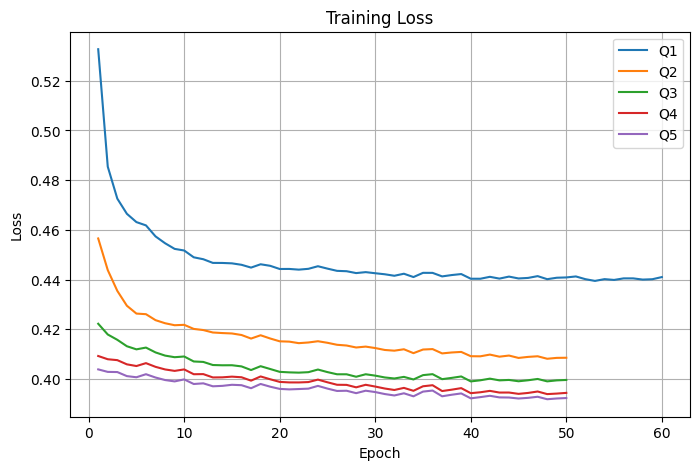

In [74]:
plt.figure(figsize=(8, 5))

for q in sorted(history_df["n_qubits"].unique()):
    subset = history_df[history_df["n_qubits"] == q]
    plt.plot(subset["epoch"], subset["loss"], label=f"Q{q}" )

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 10.4 — Curvas de Accuracy


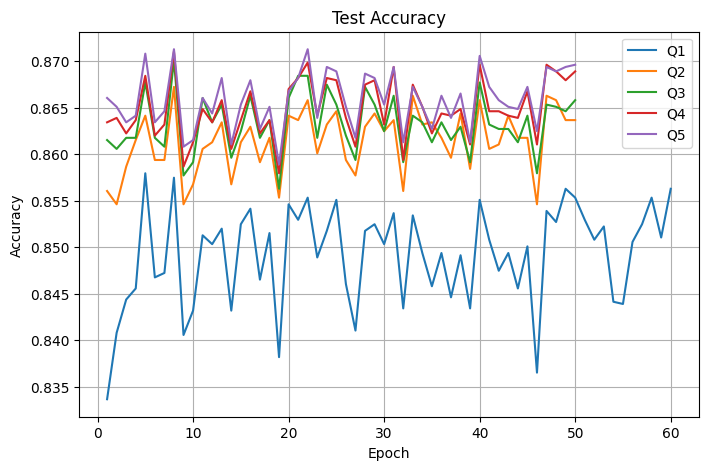

In [75]:
plt.figure(figsize=(8, 5))

for q in sorted(history_df["n_qubits"].unique()):
    subset = history_df[history_df["n_qubits"] == q]

    plt.plot(subset["epoch"], subset["test_accuracy"], label=f"Q{q}")

plt.title("Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 10.5 — Curvas de Balanced Accuracy

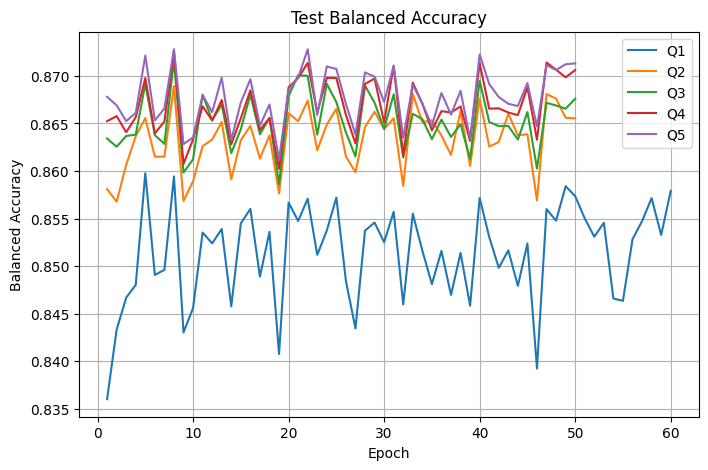

In [76]:
plt.figure(figsize=(8, 5))

for q in sorted(
    history_df["n_qubits"].unique()):
    subset = history_df[history_df["n_qubits"] == q]
    plt.plot(subset["epoch"], subset["test_balanced_accuracy"], label=f"Q{q}")

plt.title("Test Balanced Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Balanced Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 10.6 — Curvas de F1

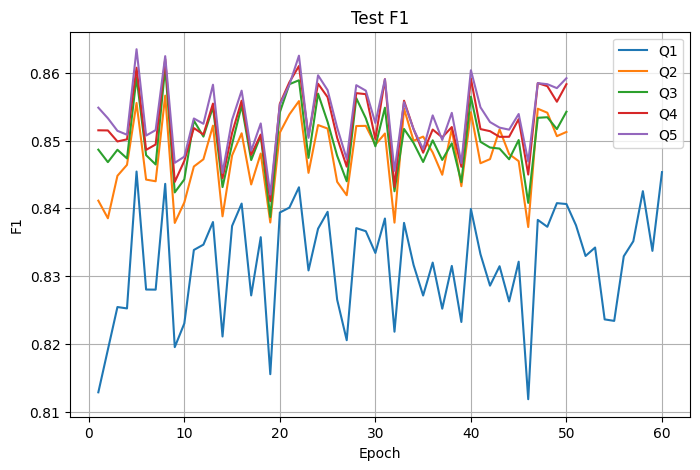

In [77]:
plt.figure(figsize=(8, 5))

for q in sorted(history_df["n_qubits"].unique()):
    subset = history_df[history_df["n_qubits"] == q]
    plt.plot(subset["epoch"], subset["test_f1"], label=f"Q{q}")

plt.title("Test F1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.legend()
plt.grid(True)
plt.show()

## 10.7 — Ranking final

In [78]:
metrics_summary_df = pd.read_csv(METRICS_PATH)

ranking_df = metrics_summary_df.sort_values(
    "test_balanced_accuracy",
    ascending=False
).reset_index(
    drop=True
)

print("\nRanking final")

display(ranking_df)


Ranking final


,n_qubits,train_accuracy,train_balanced_accuracy,train_f1,test_accuracy,test_balanced_accuracy,test_f1,checkpoint_path
0,5,0.873778,0.875231,0.865455,0.871306,0.872804,0.862455,C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN...
1,4,0.873480,0.874927,0.865181,0.871068,0.872588,0.862025,C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN...
2,3,0.872169,0.873654,0.863489,0.870114,0.871660,0.860792,C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN...
3,2,0.869428,0.871038,0.859542,0.867255,0.868933,0.856628,C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN...
4,1,0.861323,0.863123,0.849141,0.857960,0.859763,0.845436,C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN...


## 10.8 — Comparación visual Q1–Q5

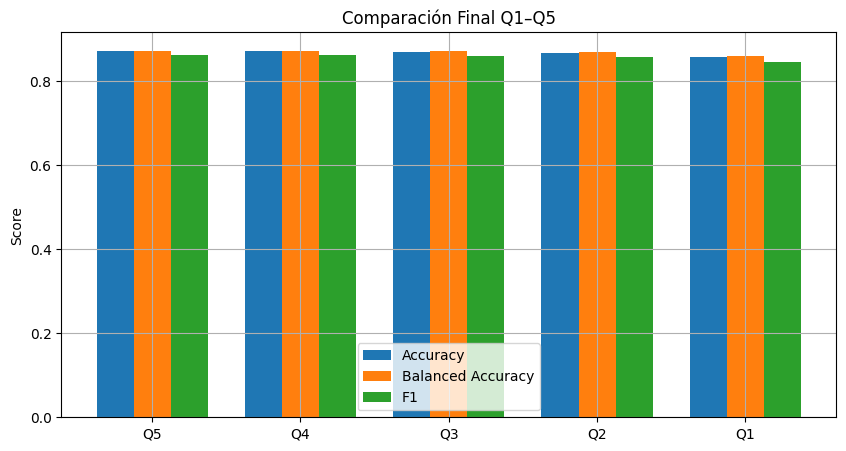

In [79]:
plt.figure(figsize=(10, 5))
x = np.arange(len(ranking_df))
width = 0.25
plt.bar(x - width, ranking_df["test_accuracy"], width=width, label="Accuracy")
plt.bar(x, ranking_df["test_balanced_accuracy"], width=width, label="Balanced Accuracy")
plt.bar(x + width, ranking_df["test_f1"], width=width, label="F1")
plt.xticks(x, [f"Q{q}" for q in ranking_df["n_qubits"]])
plt.ylabel("Score")
plt.title("Comparación Final Q1–Q5")
plt.legend()
plt.grid(True)
plt.show()

## 10.9 — Matriz de confusión del mejor modelo



Mejor modelo: Q 5


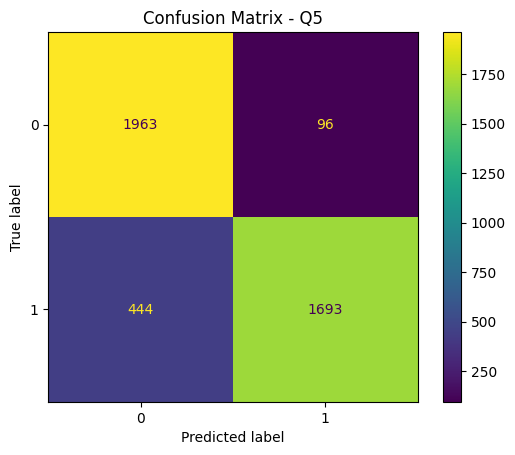

In [80]:
best_q = int(ranking_df.iloc[0]["n_qubits"])
print("\nMejor modelo: Q", best_q)
best_predictions = predictions_df[(predictions_df["n_qubits"] == best_q) & (predictions_df["split"] == "test")]

cm = confusion_matrix(best_predictions["y_true"], best_predictions["y_pred_05"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix - Q{best_q}")
plt.show()

## 10.10 — Resumen final

In [81]:
best_row = ranking_df.iloc[0]
print("\n" + "=" * 80)
print("MEJOR MODELO")
print("=" * 80)
print("Qubits:", int(best_row["n_qubits"]))
print("Test Accuracy:",  round(best_row["test_accuracy"], 6))
print("Test Balanced Accuracy:", round(best_row["test_balanced_accuracy"], 6))
print("Test F1:", round(best_row["test_f1"], 6))
print("\nCheckpoint:")
print(CHECKPOINT_PATHS[int(best_row["n_qubits"])])
print("\nNotebook finalizado.")


MEJOR MODELO
Qubits: 5
Test Accuracy: 0.871306
Test Balanced Accuracy: 0.872804
Test F1: 0.862455

Checkpoint:
C:\Users\lapic\QML5\BCAM_B_QML5\Results\DR_QNN_z64_reductions_batched\DR_QNN_BATCHED_PCA_z3_fold0\best_dr_qnn_5q.pt

Notebook finalizado.
